In [1]:
from coeur.score import Coeur
from coeur.cohesion import CohesionScore
from sentence_transformers import SentenceTransformer
from sklearn.cluster import SpectralClustering

In [2]:
coeur_scorer = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
                     remove_re_se_stopwords=True)
dataset = "trident"
R, B = coeur_scorer.load_data(ref_path=f"datasets/{dataset}/{dataset}_specs.pdf",
                cand_path=f"datasets/{dataset}/{dataset}_backlog.csv")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
EMBEDDER = SentenceTransformer("all-mpnet-base-v2")
N_EPIC = B["epic"].nunique()
PHI = SpectralClustering(n_clusters=N_EPIC, random_state=42)
LEMM = True
STEM = True
REMOVE_STOPWORDS = True
INCLUDE_AC = False
REMOVE_RE_SE_STOPWORDS = True
PENALIZE_DUPLICATES = True
METRIC = "adjusted_mutual_info"
RANDOM_STATE = 42

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
coh_scorer = CohesionScore(embedder=EMBEDDER, clusterer=PHI, lemmatization=LEMM, stemming=STEM,
                    remove_stopwords=REMOVE_STOPWORDS, include_ac=INCLUDE_AC,
                    remove_re_se_stopwords=REMOVE_RE_SE_STOPWORDS, penalize_duplicates=PENALIZE_DUPLICATES,
                    random_state=RANDOM_STATE)

In [5]:
import numpy as np

#Redundant Backlog with configurable redundancy factor
redundancy_factor = 0.5  # Proportion of rows to make redundant (0.0 to 1.0)

Bred = B.copy()
n_rows = len(Bred)
n_redundant = int(n_rows * redundancy_factor)

# Randomly select indices to make redundant
np.random.seed(42)
redundant_indices = np.random.choice(n_rows, size=n_redundant, replace=False)

# Replace selected rows with the first user_story of their own epic (intra-epic redundancy)
for idx in redundant_indices:
    epic = Bred.loc[Bred.index[idx], "epic"]
    first_story_in_epic = Bred[Bred["epic"] == epic]["user_story"].iloc[0]
    Bred.loc[Bred.index[idx], "user_story"] = first_story_in_epic

print(f"Total rows: {n_rows}, Redundant rows: {n_redundant} ({redundancy_factor*100:.0f}%)")
print(f"Unique user stories: {Bred['user_story'].nunique()}, Unique epics: {Bred['epic'].nunique()}")

Total rows: 52, Redundant rows: 26 (50%)
Unique user stories: 32, Unique epics: 14


Redundancy Factor: 0.00, Cohesion Score: 0.3694
Redundancy Factor: 0.25, Cohesion Score: 0.3715
Redundancy Factor: 0.50, Cohesion Score: 0.3697
Redundancy Factor: 0.75, Cohesion Score: 0.3272
Redundancy Factor: 1.00, Cohesion Score: 0.2690


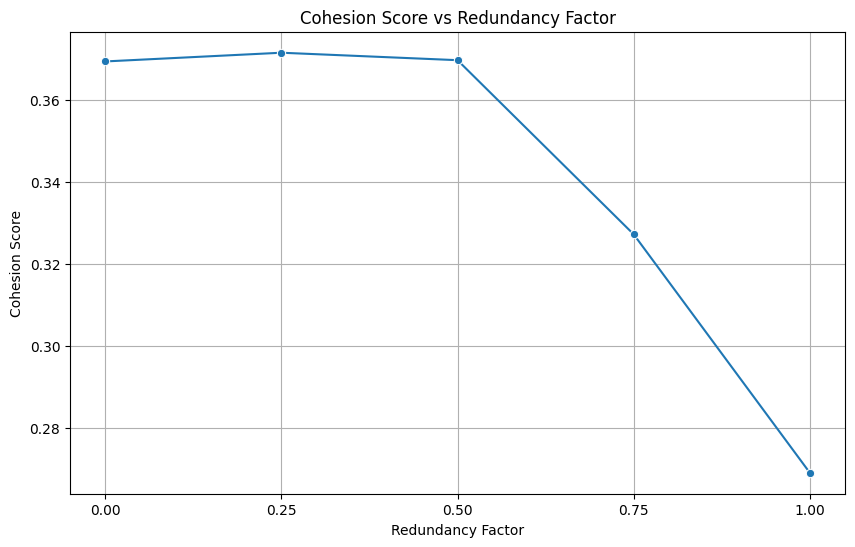

In [6]:
redundancy_factors = [0.0, 0.25, 0.5, 0.75, 1.0]
coh_results = {}
for factor in redundancy_factors:
    Bred = B.copy()
    n_rows = len(Bred)
    n_redundant = int(n_rows * factor)
    
    np.random.seed(42)
    redundant_indices = np.random.choice(n_rows, size=n_redundant, replace=False)
    
    # Replace selected rows with the first user_story of their own epic (intra-epic redundancy)
    for idx in redundant_indices:
        epic = Bred.loc[Bred.index[idx], "epic"]
        first_story_in_epic = Bred[Bred["epic"] == epic]["user_story"].iloc[0]
        Bred.loc[Bred.index[idx], "user_story"] = first_story_in_epic
    
    coh_score = coh_scorer.fit(Bred)[METRIC]
    coh_results[factor] = coh_score
    print(f"Redundancy Factor: {factor:.2f}, Cohesion Score: {coh_score:.4f}")

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
factors = list(coh_results.keys())
scores = list(coh_results.values())
plot_data = pd.DataFrame({"Redundancy Factor": factors, "Cohesion Score": scores})
# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_data, x="Redundancy Factor", y="Cohesion Score", marker="o")
plt.title("Cohesion Score vs Redundancy Factor")
plt.xlabel("Redundancy Factor")
plt.ylabel("Cohesion Score")
plt.xticks(factors)
plt.grid()
plt.show()

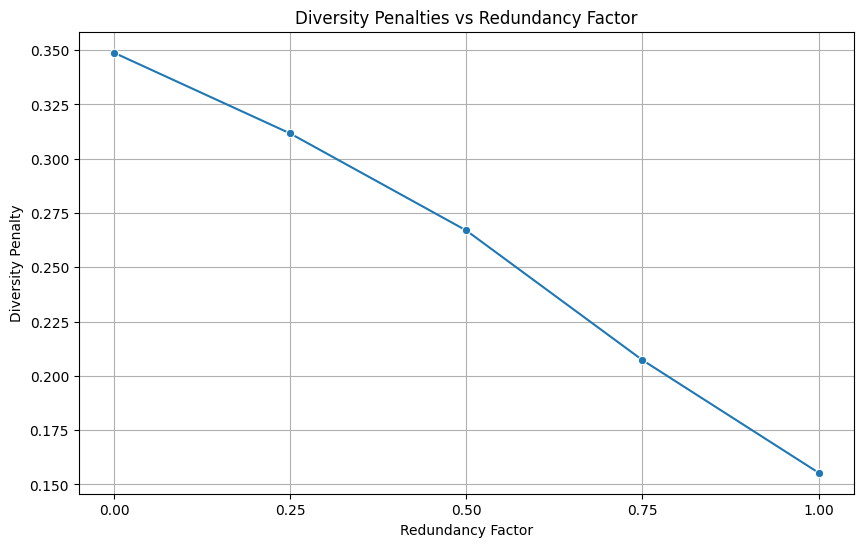

In [7]:
#plot diversity penalties in cogh_scorer.penalities
plt.figure(figsize=(10, 6))
sns.lineplot(x=redundancy_factors, y=coh_scorer.penalities, marker="o")
plt.title("Diversity Penalties vs Redundancy Factor")
plt.xlabel("Redundancy Factor")
plt.ylabel("Diversity Penalty")
plt.xticks(factors)
plt.grid()
plt.show()

Redundancy Factor: 0.00, ami : 0.3694, v_measure : 0.6998, homogeneity : 0.7157, completeness : 0.6845
Redundancy Factor: 0.25, ami : 0.3715, v_measure : 0.7255, homogeneity : 0.7249, completeness : 0.7261
Redundancy Factor: 0.50, ami : 0.3697, v_measure : 0.8000, homogeneity : 0.8098, completeness : 0.7904
Redundancy Factor: 0.75, ami : 0.3272, v_measure : 0.8872, homogeneity : 0.8950, completeness : 0.8796
Redundancy Factor: 1.00, ami : 0.2690, v_measure : 1.0000, homogeneity : 1.0000, completeness : 1.0000


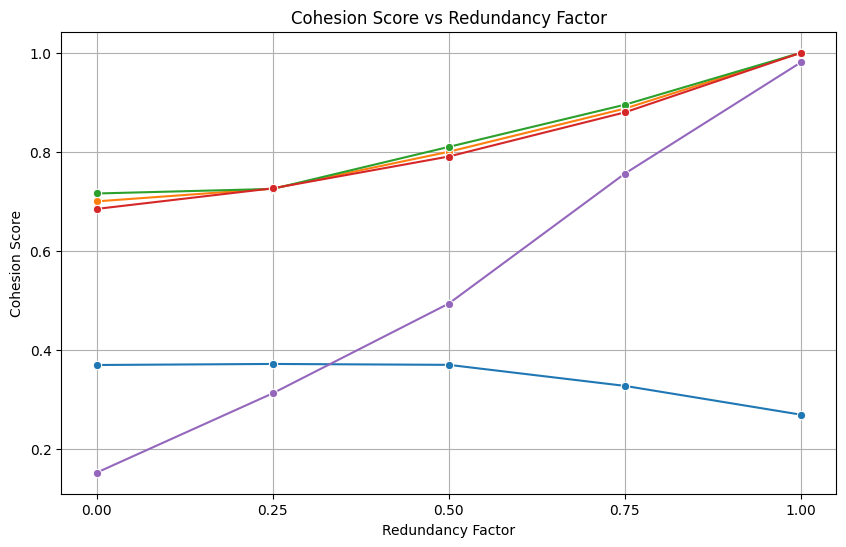

In [8]:
redundancy_factors = [0.0, 0.25, 0.5, 0.75, 1.0]
coh_results = {}
ami = {}
vm = {}
ho = {}
co = {}
si = {}
for factor in redundancy_factors:
    Bred = B.copy()
    n_rows = len(Bred)
    n_redundant = int(n_rows * factor)
    
    np.random.seed(42)
    redundant_indices = np.random.choice(n_rows, size=n_redundant, replace=False)
    
    # Replace selected rows with the first user_story of their own epic (intra-epic redundancy)
    for idx in redundant_indices:
        epic = Bred.loc[Bred.index[idx], "epic"]
        first_story_in_epic = Bred[Bred["epic"] == epic]["user_story"].iloc[0]
        Bred.loc[Bred.index[idx], "user_story"] = first_story_in_epic
    
    coh_score = coh_scorer.fit(Bred)
    ami[factor] = coh_score["adjusted_mutual_info"]
    vm[factor] = coh_score["v_measure"]
    ho[factor] = coh_score["homogeneity"]
    co[factor] = coh_score["completeness"]
    si[factor] = coh_score["silhouette"]
    # coh_results[factor] = coh_score
    print(f"Redundancy Factor: {factor:.2f}, ami : {ami[factor]:.4f}, v_measure : {vm[factor]:.4f}, homogeneity : {ho[factor]:.4f}, completeness : {co[factor]:.4f}")

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for plotting
factors = list(ami.keys())
plot_data = pd.DataFrame({
    "Redundancy Factor": factors,
    "Adjusted Mutual Info": [ami[f] for f in factors],
    "V-Measure": [vm[f] for f in factors],
    "Homogeneity": [ho[f] for f in factors],
    "Completeness": [co[f] for f in factors],
    "Silhouette Score": [si[f] for f in factors]
})
# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_data, x="Redundancy Factor", y="Adjusted Mutual Info", marker="o")
sns.lineplot(data=plot_data, x="Redundancy Factor", y="V-Measure", marker="o")
sns.lineplot(data=plot_data, x="Redundancy Factor", y="Homogeneity", marker="o")
sns.lineplot(data=plot_data, x="Redundancy Factor", y="Completeness", marker="o")
sns.lineplot(data=plot_data, x="Redundancy Factor", y="Silhouette Score", marker="o")
plt.title("Cohesion Score vs Redundancy Factor")
plt.xlabel("Redundancy Factor")
plt.ylabel("Cohesion Score")
plt.xticks(factors)
plt.grid()
plt.show()